## Лабораторная работа №4

### Цель работы
Изучение линейных моделей (логистическая регрессия), метода опорных векторов (SVM) и деревьев решений для задачи классификации; сравнение качества моделей и анализ важности признаков.

### Описание датасета
Использован датасет *Breast Cancer Wisconsin* — задача бинарной классификации: предсказание злокачественности опухоли молочной железы по 30 числовым признакам (радиус, текстура, периметр и т.д.). Датасет содержит 569 наблюдений, пропущенных значений нет.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score

In [4]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target   # 0 = malignant (злокачественная), 1 = benign (доброкачественная)
print(f"Форма датасета: {df.shape}")
df.head()

Форма датасета: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [6]:
print("Пропущенные значения:")
print(df.isna().sum())
print(f"\nРаспределение целевого признака:")
print(df["target"].value_counts())

Пропущенные значения:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Распределение целевого признака:
target
1    357
0    212
Name: c

### Подготовка данных

Датасет не содержит пропущенных значений. Все 30 признаков числовые (среднее, стандартное отклонение и худшее значение радиуса, текстуры, периметра и т.д.). Масштабируем с помощью `StandardScaler`.


In [7]:
y = df["target"]
X = df.drop("target", axis=1)
print(f"Признаков: {X.shape[1]}, наблюдений: {X.shape[0]}")

Признаков: 30, наблюдений: 569


### Масштабирование данных


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Разделение данных


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка:  {X_test.shape[0]} наблюдений")

Обучающая выборка: 398 наблюдений
Тестовая выборка:  171 наблюдений


### Обучение моделей


In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print(f"Логистическая регрессия — Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}, F1: {f1_score(y_test, y_pred_lr):.4f}")

Логистическая регрессия — Accuracy: 0.9825, F1: 0.9860


In [11]:
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print(f"SVM (RBF) — Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}, F1: {f1_score(y_test, y_pred_svm):.4f}")

SVM (RBF) — Accuracy: 0.9766, F1: 0.9813


In [12]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print(f"Дерево решений — Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}, F1: {f1_score(y_test, y_pred_dt):.4f}")

Дерево решений — Accuracy: 0.9298, F1: 0.9439


### Оценка качества моделей


,Accuracy,F1-score
Модель,,
Логистическая регрессия,0.9825,0.9860
SVM,0.9766,0.9813
Дерево решений,0.9298,0.9439


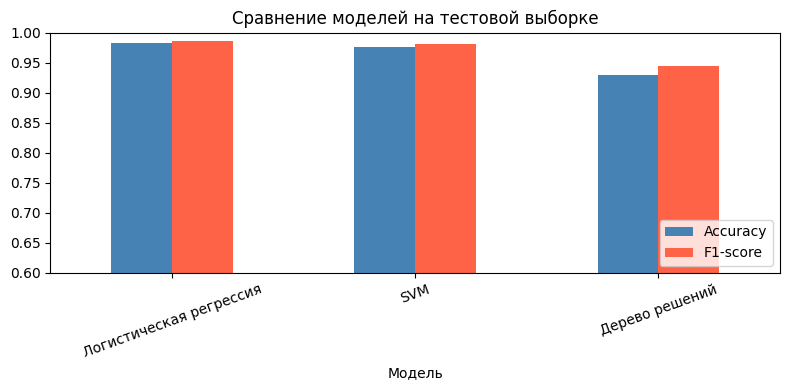

In [13]:
results = pd.DataFrame({
    "Модель": ["Логистическая регрессия", "SVM", "Дерево решений"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_dt)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_dt)
    ]
}).set_index("Модель").round(4)

display(results)

fig, ax = plt.subplots(figsize=(8, 4))
results.plot(kind="bar", ax=ax, rot=20, color=["steelblue", "tomato"])
ax.set_title("Сравнение моделей на тестовой выборке")
ax.set_ylim(0.6, 1.0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Важность признаков (дерево решений)


Важность признаков (убывание):
  worst radius   : 0.7270
  worst concave points: 0.1314
  worst texture  : 0.0501
  texture error  : 0.0307
  worst concavity: 0.0190
  mean fractal dimension: 0.0104
  worst area     : 0.0094
  worst compactness: 0.0088
  worst fractal dimension: 0.0073
  smoothness error: 0.0033
  area error     : 0.0026
  fractal dimension error: 0.0000
  mean symmetry  : 0.0000
  mean texture   : 0.0000
  mean perimeter : 0.0000
  mean area      : 0.0000
  mean smoothness: 0.0000
  mean compactness: 0.0000
  mean concavity : 0.0000
  mean concave points: 0.0000
  worst smoothness: 0.0000
  symmetry error : 0.0000
  radius error   : 0.0000
  worst perimeter: 0.0000
  perimeter error: 0.0000
  worst symmetry : 0.0000
  compactness error: 0.0000
  concavity error: 0.0000
  concave points error: 0.0000
  mean radius    : 0.0000


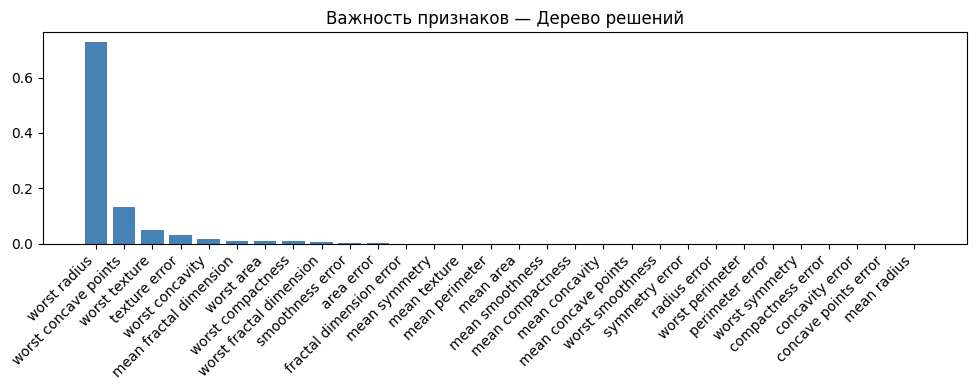

In [14]:
feature_names = X.columns.tolist()
importances = dt.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Важность признаков (убывание):")
for i in range(len(feature_names)):
    print(f"  {feature_names[sorted_idx[i]]:<15}: {importances[sorted_idx[i]]:.4f}")

plt.figure(figsize=(10, 4))
plt.bar(range(len(importances)), importances[sorted_idx], color="steelblue")
plt.xticks(range(len(importances)), [feature_names[i] for i in sorted_idx], rotation=45, ha="right")
plt.title("Важность признаков — Дерево решений")
plt.tight_layout()
plt.show()

### Визуализация дерева решений


In [15]:
print("Правила дерева решений (до глубины 3):")
print(export_text(dt, feature_names=feature_names, max_depth=3))

Правила дерева решений (до глубины 3):
|--- worst radius <= 0.11
|   |--- worst concave points <= 0.43
|   |   |--- smoothness error <= -1.25
|   |   |   |--- worst fractal dimension <= -0.73
|   |   |   |   |--- class: 1
|   |   |   |--- worst fractal dimension >  -0.73
|   |   |   |   |--- class: 0
|   |   |--- smoothness error >  -1.25
|   |   |   |--- area error <= -0.11
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- area error >  -0.11
|   |   |   |   |--- truncated branch of depth 2
|   |--- worst concave points >  0.43
|   |   |--- worst texture <= -0.32
|   |   |   |--- worst area <= -0.15
|   |   |   |   |--- class: 1
|   |   |   |--- worst area >  -0.15
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  -0.32
|   |   |   |--- mean fractal dimension <= -0.27
|   |   |   |   |--- class: 1
|   |   |   |--- mean fractal dimension >  -0.27
|   |   |   |   |--- class: 0
|--- worst radius >  0.11
|   |--- texture error <= -1.38
|   |   |--- class: 1
|   |

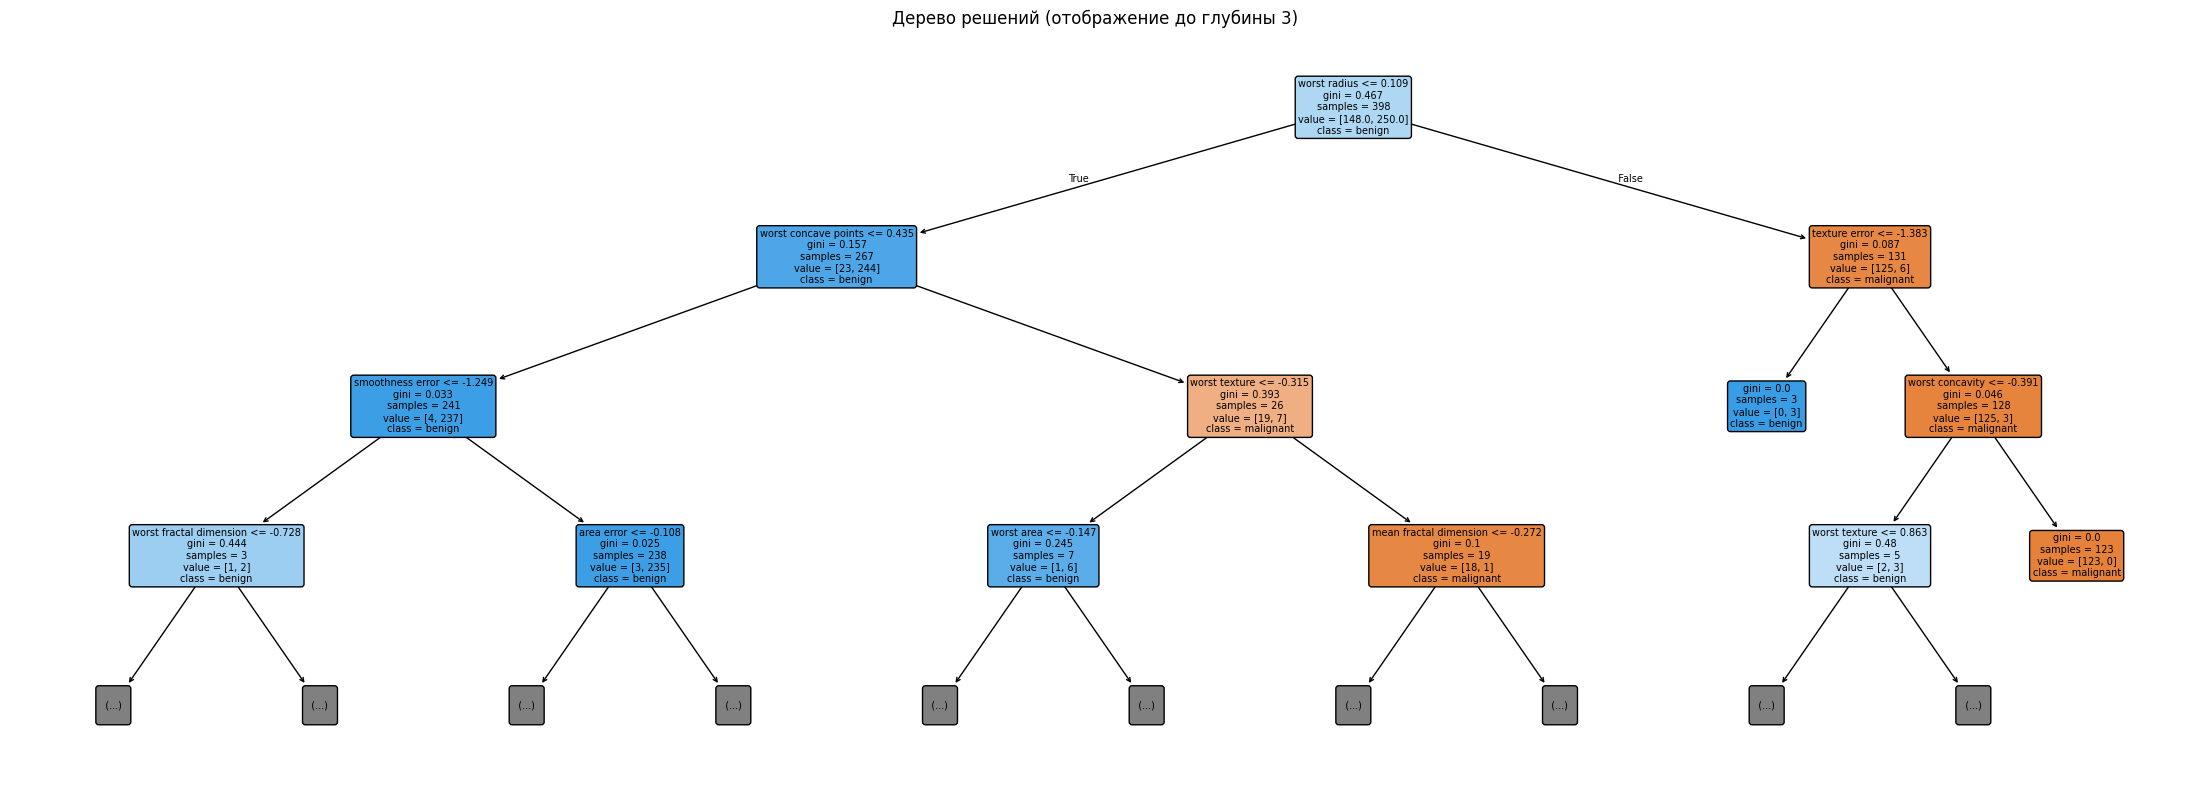

In [16]:
plt.figure(figsize=(22, 8))
plot_tree(
    dt,
    feature_names=list(data.feature_names),
    class_names=data.target_names.tolist(),
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3
)
plt.title("Дерево решений (отображение до глубины 3)")
plt.tight_layout()
plt.show()

## Выводы

Для задачи классификации опухолей молочной железы обучены три модели: логистическая регрессия, SVM с RBF-ядром и дерево решений (max_depth=5). В качестве метрик использованы **Accuracy** и **F1-score**.

Логистическая регрессия и SVM показали высокое качество благодаря хорошей линейной разделимости классов в 30-мерном пространстве масштабированных признаков. Дерево решений с ограниченной глубиной незначительно уступает, но остаётся интерпретируемым и наглядным.

Наиболее значимыми признаками по версии дерева решений оказались `worst radius` и `worst concave points` — геометрические характеристики худшего среза клетки, которые наиболее информативны для разделения злокачественных и доброкачественных опухолей.
